`p043774.mat`

In [3]:
import h5py

MAT_FILE = "/content/drive/MyDrive/Colab Notebooks/PusleDB/p043774.mat"

def list_keys(obj, prefix=""):
    keys = list(obj.keys())
    print(prefix + "keys:", keys)
    return keys

with h5py.File(MAT_FILE, "r") as f:
    print("=== TOP LEVEL ===")
    top_keys = list_keys(f)

    # Subj_Wins가 있는지 확인
    if "Subj_Wins" not in f:
        raise KeyError("No 'Subj_Wins' group found. Check the file structure above.")

    print("\n=== Subj_Wins ===")
    sw = f["Subj_Wins"]
    sw_keys = list_keys(sw, prefix="Subj_Wins ")

    # 우리가 기대하는 필드가 있는지 확인
    expected = ["PPG_F", "SegSBP", "SegDBP"]
    for k in expected:
        print(f"Exists {k}?:", (k in sw))

    # 참조 배열 형태 확인: 보통 [0]에 길이 N짜리 ref array가 있음
    ppg_refs = sw["PPG_F"][0]
    sbp_refs = sw["SegSBP"][0]
    dbp_refs = sw["SegDBP"][0]

    print("\n=== LENGTHS ===")
    print("Num segments (PPG_F):", len(ppg_refs))
    print("Num segments (SegSBP):", len(sbp_refs))
    print("Num segments (SegDBP):", len(dbp_refs))

    # 샘플 하나의 타입 확인(레퍼런스인지, 데이터셋인지)
    print("\n=== SAMPLE REF TYPE CHECK ===")
    print("type(ppg_refs[0]) :", type(ppg_refs[0]))
    print("type(sbp_refs[0]) :", type(sbp_refs[0]))
    print("type(dbp_refs[0]) :", type(dbp_refs[0]))

    # 실제로 첫 세그먼트의 PPG 길이와 첫 라벨 값이 읽히는지 확인
    ppg0 = f[ppg_refs[0]][()]
    sbp0 = f[sbp_refs[0]][()]
    dbp0 = f[dbp_refs[0]][()]

    print("\n=== FIRST ITEM SHAPES ===")
    print("PPG[0] raw shape:", ppg0.shape)
    print("SBP[0] raw shape:", sbp0.shape, "value example:", sbp0.flatten()[:5])
    print("DBP[0] raw shape:", dbp0.shape, "value example:", dbp0.flatten()[:5])


=== TOP LEVEL ===
keys: ['#refs#', 'Subj_Wins']

=== Subj_Wins ===
Subj_Wins keys: ['ABP_F', 'ABP_Lag', 'ABP_Raw', 'ABP_SPeaks', 'ABP_Turns', 'Age', 'CaseID', 'ECG_F', 'ECG_RPeaks', 'ECG_Raw', 'ECG_Record', 'ECG_Record_F', 'Gender', 'IncludeFlag', 'PPG_ABP_Corr', 'PPG_F', 'PPG_Raw', 'PPG_Record', 'PPG_Record_F', 'PPG_SPeaks', 'PPG_Turns', 'SegDBP', 'SegSBP', 'SegmentID', 'SubjectID', 'T', 'WinID', 'WinSeqID']
Exists PPG_F?: True
Exists SegSBP?: True
Exists SegDBP?: True

=== LENGTHS ===
Num segments (PPG_F): 1943
Num segments (SegSBP): 1943
Num segments (SegDBP): 1943

=== SAMPLE REF TYPE CHECK ===
type(ppg_refs[0]) : <class 'h5py.h5r.Reference'>
type(sbp_refs[0]) : <class 'h5py.h5r.Reference'>
type(dbp_refs[0]) : <class 'h5py.h5r.Reference'>

=== FIRST ITEM SHAPES ===
PPG[0] raw shape: (1, 1250)
SBP[0] raw shape: (1, 1) value example: [99.1372503]
DBP[0] raw shape: (1, 1) value example: [53.41768858]


=== Field presence check ===
T            exists? True
WinSeqID     exists? True
WinID        exists? True
SegmentID    exists? True
CaseID       exists? True
SubjectID    exists? True
IncludeFlag  exists? True
PPG_ABP_Corr exists? True
ABP_Lag      exists? True

Num segments: 1943

[T]
  ref type: <class 'h5py.h5r.Reference'>
  first raw shape: (1, 1250) dtype: float64
  first values (flatten head): [0.008 0.016 0.024]

[WinSeqID]
  ref type: <class 'h5py.h5r.Reference'>
  first raw shape: (1, 1) dtype: float64
  first values (flatten head): [1.]

[WinID]
  ref type: <class 'h5py.h5r.Reference'>
  first raw shape: (1, 1) dtype: float64
  first values (flatten head): [1.]

[SegmentID]
  ref type: <class 'h5py.h5r.Reference'>
  first raw shape: (1, 1) dtype: float64
  first values (flatten head): [1.]

[CaseID]
  ref type: <class 'h5py.h5r.Reference'>
  first raw shape: (16, 1) dtype: uint16
  first values (flatten head): [50 49 52]

[SubjectID]
  ref type: <class 'h5py.h5r.Reference'>


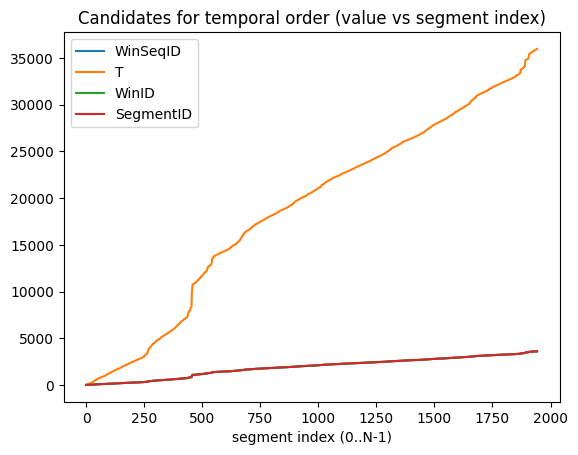

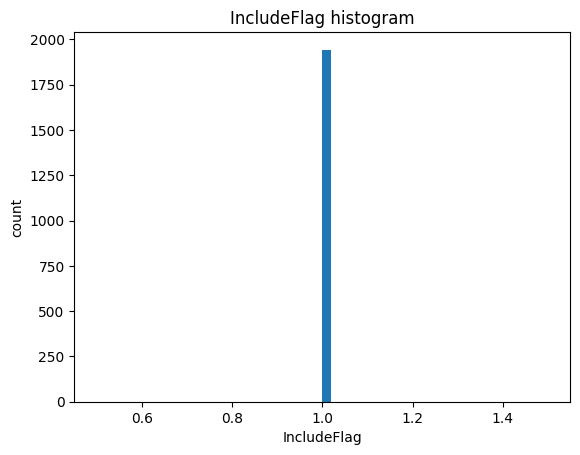

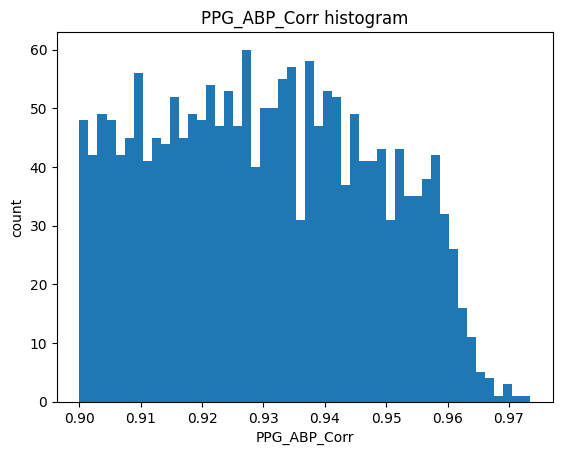

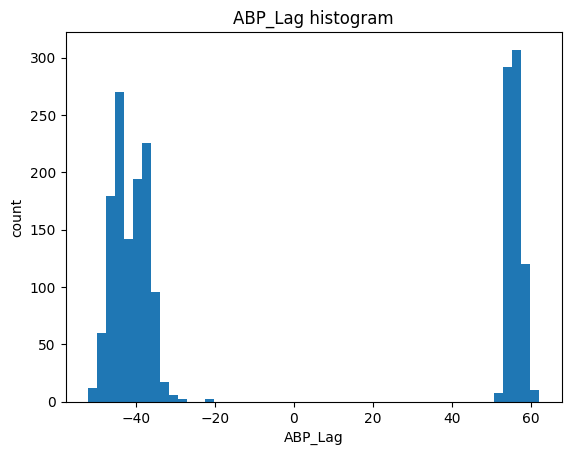

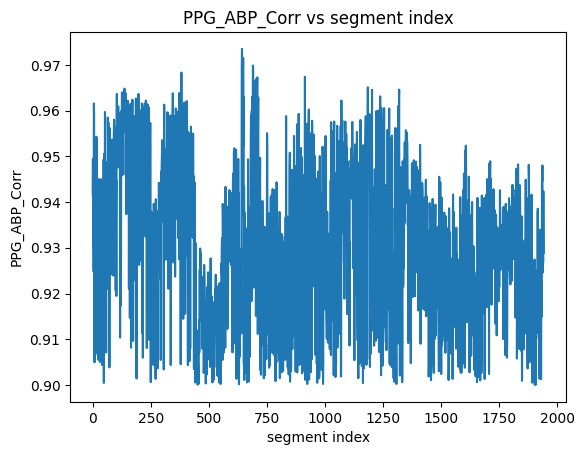

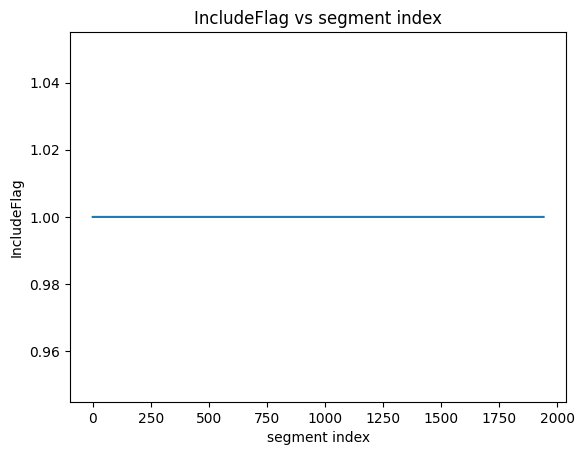

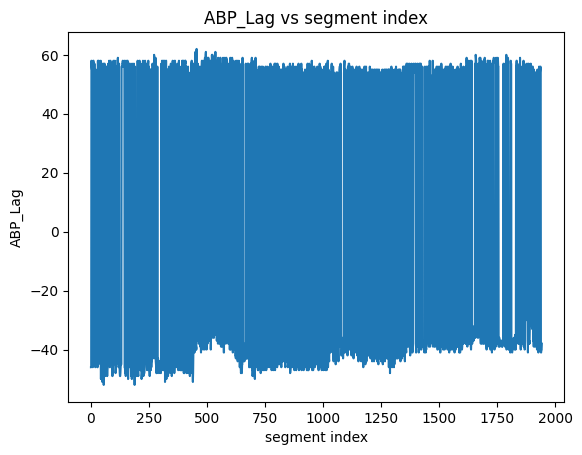

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

MAT_FILE = "/content/drive/MyDrive/Colab Notebooks/PusleDB/p043774.mat"

def read_ref_scalar(f, ref):
    """(1,1) 같은 스칼라 dataset ref에서 float로 읽기"""
    arr = f[ref][()]
    return float(np.array(arr).reshape(-1)[0])

def read_ref_vec(f, ref):
    """벡터(예: (1,N) 또는 (N,1)) dataset ref를 1D로 읽기"""
    arr = np.array(f[ref][()]).squeeze()
    return arr

with h5py.File(MAT_FILE, "r") as f:
    sw = f["Subj_Wins"]

    # 후보 필드들(시간/순서/ID)
    cand_ids = ["T", "WinSeqID", "WinID", "SegmentID", "CaseID", "SubjectID"]
    # 품질/정렬 관련
    cand_q = ["IncludeFlag", "PPG_ABP_Corr", "ABP_Lag"]

    print("=== Field presence check ===")
    for k in cand_ids + cand_q:
        print(f"{k:12s} exists? {k in sw}")

    # ref arrays
    n = len(sw["PPG_F"][0])
    print("\nNum segments:", n)

    # 1) 각 후보 필드의 'shape/type' 파악
    def inspect_ref_field(name, max_show=3):
        refs = sw[name][0]
        r0 = refs[0]
        data0 = f[r0][()]
        data0_np = np.array(data0)
        print(f"\n[{name}]")
        print("  ref type:", type(r0))
        print("  first raw shape:", data0_np.shape, "dtype:", data0_np.dtype)
        print("  first values (flatten head):", data0_np.reshape(-1)[:max_show])

    for name in cand_ids + cand_q:
        if name in sw:
            inspect_ref_field(name)

    # 2) 실제 값 배열로 읽어서 통계/단조성 확인 (빠르게 1943개 전부 읽기)
    def read_field_all(name):
        refs = sw[name][0]
        vals = np.zeros(n, dtype=np.float64)
        for i in range(n):
            vals[i] = read_ref_scalar(f, refs[i])
        return vals

    id_arrays = {}
    q_arrays = {}

    for name in cand_ids:
        if name in sw:
            id_arrays[name] = read_field_all(name)

    for name in cand_q:
        if name in sw:
            q_arrays[name] = read_field_all(name)

# ---- (A) 시간/순서 후보 통계 출력 ----
print("\n=== ID/TIME candidate stats ===")
for name, arr in id_arrays.items():
    arr_int_like = np.all(np.isclose(arr, np.round(arr)))
    uniq = len(np.unique(arr))
    dif = np.diff(arr)
    mono_inc = np.all(dif >= 0)
    mono_strict = np.all(dif > 0)
    print(f"{name:10s} | min={arr.min():.3f} max={arr.max():.3f} uniq={uniq} "
          f"| int_like={arr_int_like} | nondecreasing={mono_inc} strict_inc={mono_strict}")

# ---- (B) 품질 후보 통계 출력 ----
print("\n=== QUALITY candidate stats ===")
for name, arr in q_arrays.items():
    uniq = len(np.unique(arr))
    print(f"{name:12s} | min={arr.min():.4f} max={arr.max():.4f} mean={arr.mean():.4f} "
          f"std={arr.std():.4f} uniq={uniq}")

# ---- (C) 시각화: 인덱스에 따른 변화 (시간순서/품질이 연속인지 감) ----
# 1) 시간 후보들(라인 플롯)
plt.figure()
for name in ["WinSeqID", "T", "WinID", "SegmentID"]:
    if name in id_arrays:
        plt.plot(id_arrays[name], label=name)
plt.title("Candidates for temporal order (value vs segment index)")
plt.xlabel("segment index (0..N-1)")
plt.legend()
plt.show()

# 2) 품질 지표 히스토그램
for name in ["IncludeFlag", "PPG_ABP_Corr", "ABP_Lag"]:
    if name in q_arrays:
        plt.figure()
        plt.hist(q_arrays[name], bins=50)
        plt.title(f"{name} histogram")
        plt.xlabel(name); plt.ylabel("count")
        plt.show()

# 3) PPG_ABP_Corr vs index (시간에 따라 품질이 나빠지는 구간이 있는지)
if "PPG_ABP_Corr" in q_arrays:
    plt.figure()
    plt.plot(q_arrays["PPG_ABP_Corr"])
    plt.title("PPG_ABP_Corr vs segment index")
    plt.xlabel("segment index"); plt.ylabel("PPG_ABP_Corr")
    plt.show()

# 4) IncludeFlag vs index
if "IncludeFlag" in q_arrays:
    plt.figure()
    plt.plot(q_arrays["IncludeFlag"])
    plt.title("IncludeFlag vs segment index")
    plt.xlabel("segment index"); plt.ylabel("IncludeFlag")
    plt.show()

# 5) ABP_Lag vs index
if "ABP_Lag" in q_arrays:
    plt.figure()
    plt.plot(q_arrays["ABP_Lag"])
    plt.title("ABP_Lag vs segment index")
    plt.xlabel("segment index"); plt.ylabel("ABP_Lag")
    plt.show()


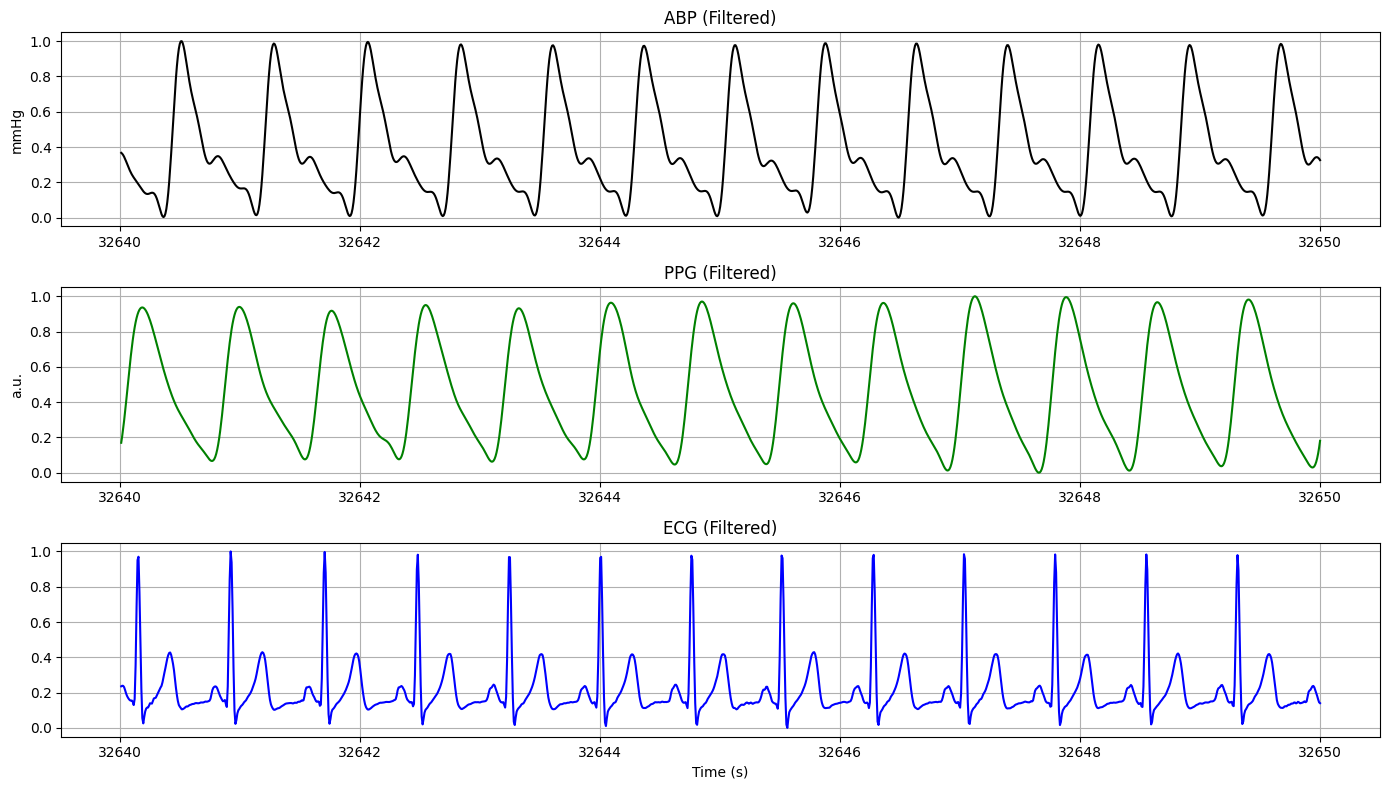

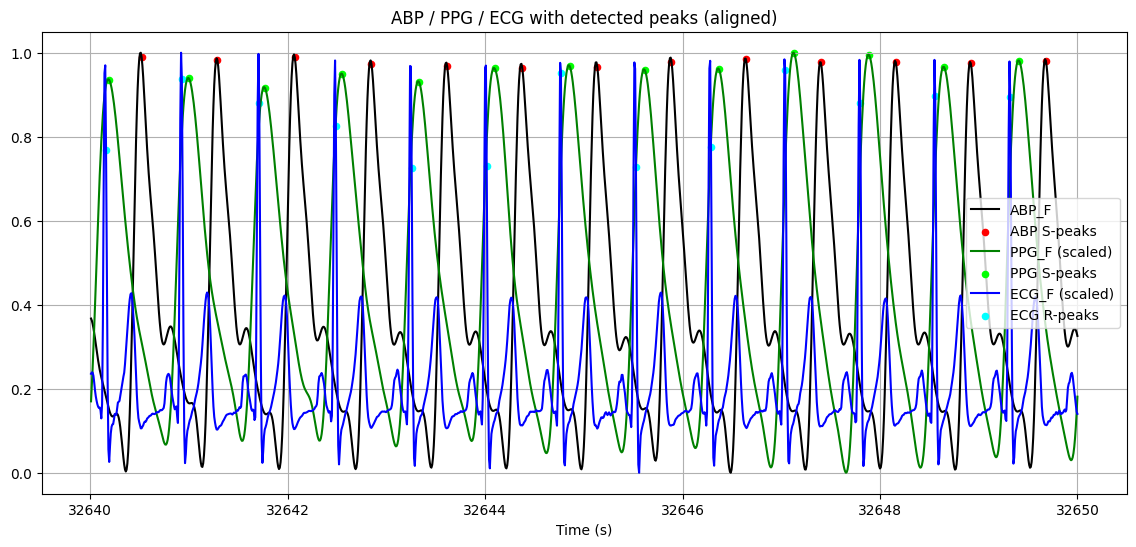

In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

MAT_FILE = "/content/drive/MyDrive/Colab Notebooks/PusleDB/p043774.mat"

def read_vec(f, ref):
    return np.array(f[ref][()]).squeeze()

idx = 1818  # 보고 싶은 segment index (0, 100, 500 등으로 바꿔도 됨)

with h5py.File(MAT_FILE, "r") as f:
    sw = f["Subj_Wins"]

    # signals
    ppg_raw = read_vec(f, sw["PPG_Raw"][0][idx])
    ppg_f   = read_vec(f, sw["PPG_F"][0][idx])

    abp_raw = read_vec(f, sw["ABP_Raw"][0][idx])
    abp_f   = read_vec(f, sw["ABP_F"][0][idx])

    ecg_raw = read_vec(f, sw["ECG_Raw"][0][idx])
    ecg_f   = read_vec(f, sw["ECG_F"][0][idx])

    t = read_vec(f, sw["T"][0][idx])  # time axis (length 1250)
plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(t, abp_f, label="ABP_F", color="black")
plt.title("ABP (Filtered)")
plt.ylabel("mmHg")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, ppg_f, label="PPG_F", color="green")
plt.title("PPG (Filtered)")
plt.ylabel("a.u.")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, ecg_f, label="ECG_F", color="blue")
plt.title("ECG (Filtered)")
plt.xlabel("Time (s)")
plt.grid(True)

plt.tight_layout()
plt.show()

with h5py.File(MAT_FILE, "r") as f:
    sw = f["Subj_Wins"]

    ppg_sp = read_vec(f, sw["PPG_SPeaks"][0][idx]).astype(int)
    abp_sp = read_vec(f, sw["ABP_SPeaks"][0][idx]).astype(int)
    ecg_rp = read_vec(f, sw["ECG_RPeaks"][0][idx]).astype(int)

plt.figure(figsize=(14, 6))
plt.plot(t, abp_f, label="ABP_F", color="black")
plt.scatter(t[abp_sp], abp_f[abp_sp], c="red", s=20, label="ABP S-peaks")

plt.plot(t, ppg_f / np.max(ppg_f) * np.max(abp_f),
         label="PPG_F (scaled)", color="green")
plt.scatter(t[ppg_sp],
            (ppg_f / np.max(ppg_f) * np.max(abp_f))[ppg_sp],
            c="lime", s=20, label="PPG S-peaks")

plt.plot(t, ecg_f / np.max(ecg_f) * np.max(abp_f),
         label="ECG_F (scaled)", color="blue")
plt.scatter(t[ecg_rp],
            (ecg_f / np.max(ecg_f) * np.max(abp_f))[ecg_rp],
            c="cyan", s=20, label="ECG R-peaks")

plt.legend()
plt.title("ABP / PPG / ECG with detected peaks (aligned)")
plt.xlabel("Time (s)")
plt.grid(True)
plt.show()


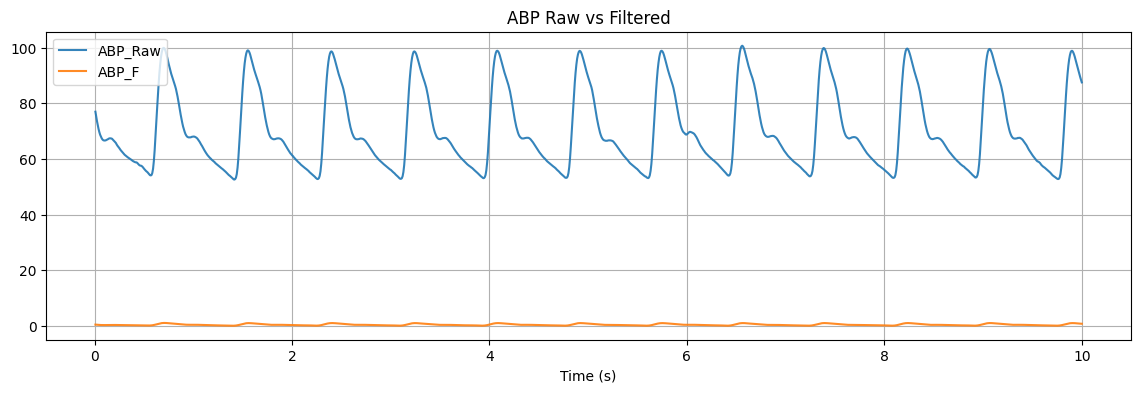

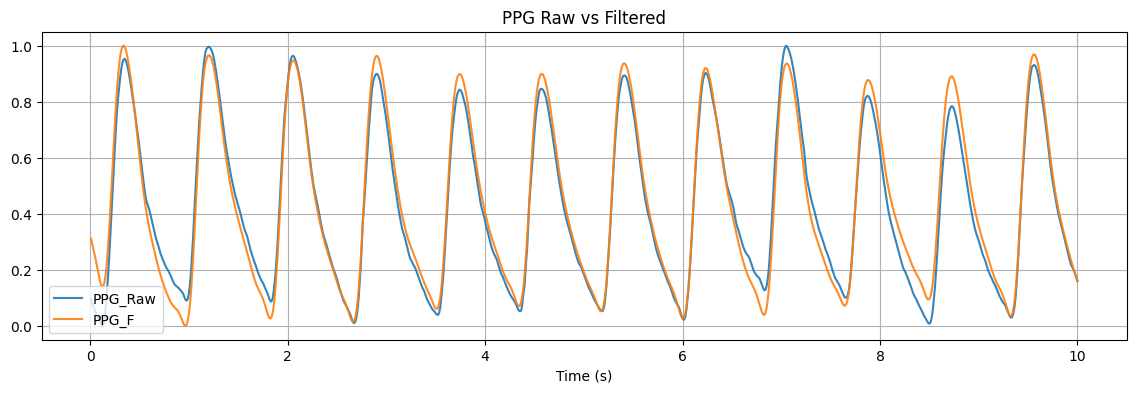

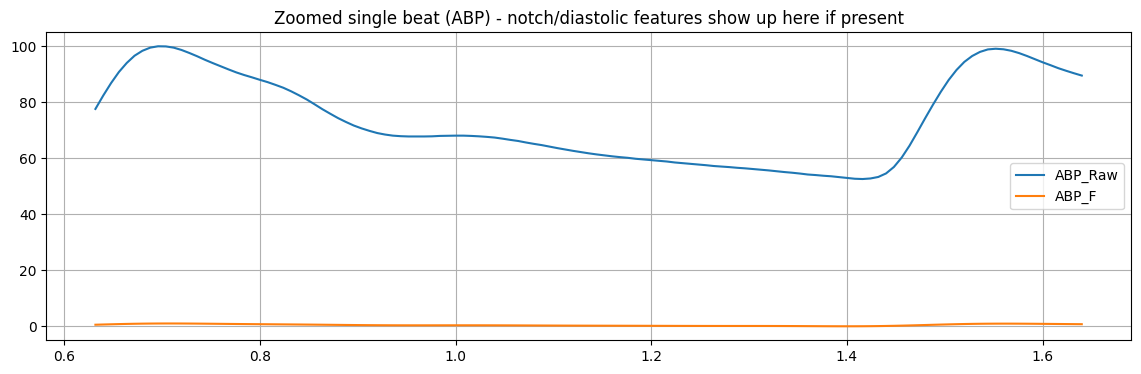

In [9]:
import h5py, numpy as np, matplotlib.pyplot as plt

MAT_FILE = "/content/drive/MyDrive/Colab Notebooks/PusleDB/p043774.mat"

def read_vec(f, ref):
    return np.array(f[ref][()]).squeeze()

idx = 0  # 방금 본 그 idx로 맞춰줘

with h5py.File(MAT_FILE, "r") as f:
    sw = f["Subj_Wins"]
    t = read_vec(f, sw["T"][0][idx])

    abp_raw = read_vec(f, sw["ABP_Raw"][0][idx])
    abp_f   = read_vec(f, sw["ABP_F"][0][idx])

    ppg_raw = read_vec(f, sw["PPG_Raw"][0][idx])
    ppg_f   = read_vec(f, sw["PPG_F"][0][idx])

# 1) Raw vs F 비교 (ABP)
plt.figure(figsize=(14,4))
plt.plot(t, abp_raw, label="ABP_Raw", alpha=0.9)
plt.plot(t, abp_f,   label="ABP_F",   alpha=0.9)
plt.title("ABP Raw vs Filtered")
plt.xlabel("Time (s)")
plt.grid(True); plt.legend()
plt.show()

# 2) Raw vs F 비교 (PPG)
plt.figure(figsize=(14,4))
plt.plot(t, ppg_raw, label="PPG_Raw", alpha=0.9)
plt.plot(t, ppg_f,   label="PPG_F",   alpha=0.9)
plt.title("PPG Raw vs Filtered")
plt.xlabel("Time (s)")
plt.grid(True); plt.legend()
plt.show()

# 3) 한 박동만 확대 (ABP) - systolic peak 기준으로 한 구간 자르기
# PulseDB peak index 활용
with h5py.File(MAT_FILE, "r") as f:
    sw = f["Subj_Wins"]
    abp_sp = read_vec(f, sw["ABP_SPeaks"][0][idx]).astype(int)

if len(abp_sp) >= 2:
    # 첫 peak와 다음 peak 사이를 한 beat로 보고 확대
    s = abp_sp[0]
    e = abp_sp[1]
    pad = 10
    s2 = max(0, s - pad)
    e2 = min(len(t)-1, e + pad)

    plt.figure(figsize=(14,4))
    plt.plot(t[s2:e2], abp_raw[s2:e2], label="ABP_Raw")
    plt.plot(t[s2:e2], abp_f[s2:e2],   label="ABP_F")
    plt.title("Zoomed single beat (ABP) - notch/diastolic features show up here if present")
    plt.grid(True); plt.legend()
    plt.show()
else:
    print("Not enough ABP_SPeaks to zoom a single beat.")


N segments: 1943
SBP: mean±std = 110.12 ± 12.19 | min/median/max = 90.06 / 107.59 / 138.19
DBP: mean±std = 59.29 ± 5.89 | min/median/max = 45.01 / 59.10 / 72.63


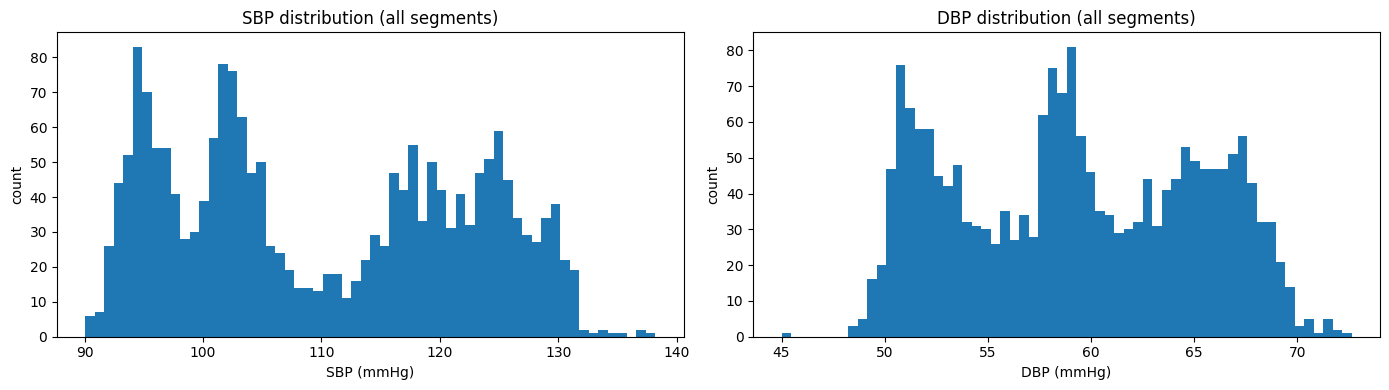

/tmp/ipython-input-3184767439.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sbp, dbp], labels=["SBP", "DBP"], showfliers=True)


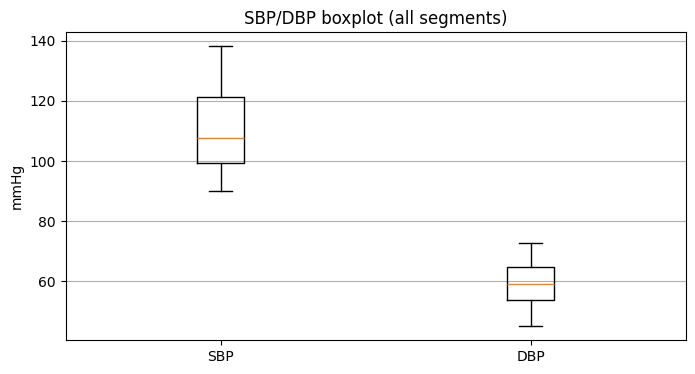

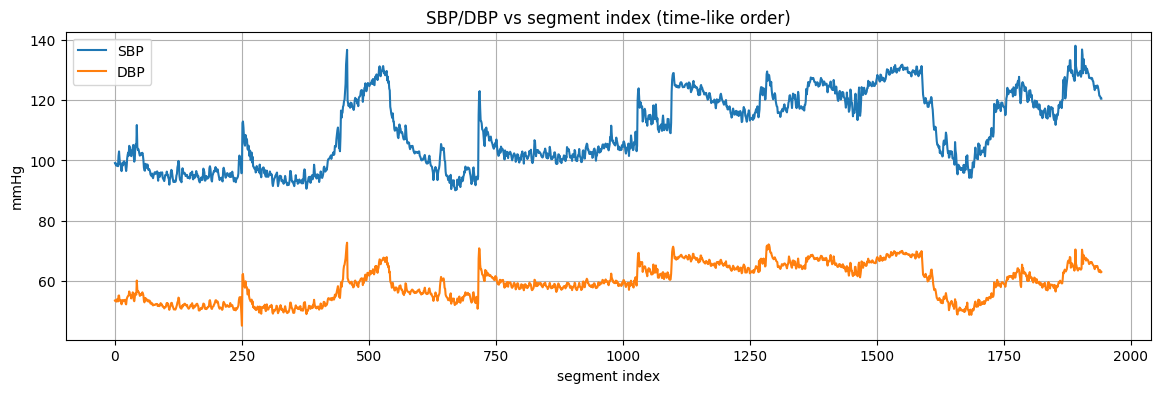

In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

MAT_FILE = "/content/drive/MyDrive/Colab Notebooks/PusleDB/p043774.mat"

def read_scalar(f, ref):
    return float(np.array(f[ref][()]).reshape(-1)[0])

with h5py.File(MAT_FILE, "r") as f:
    sw = f["Subj_Wins"]
    n = len(sw["SegSBP"][0])

    sbp = np.zeros(n, dtype=np.float32)
    dbp = np.zeros(n, dtype=np.float32)

    sbp_refs = sw["SegSBP"][0]
    dbp_refs = sw["SegDBP"][0]

    for i in range(n):
        sbp[i] = read_scalar(f, sbp_refs[i])
        dbp[i] = read_scalar(f, dbp_refs[i])

print("N segments:", n)
print(f"SBP: mean±std = {sbp.mean():.2f} ± {sbp.std():.2f} | min/median/max = {sbp.min():.2f} / {np.median(sbp):.2f} / {sbp.max():.2f}")
print(f"DBP: mean±std = {dbp.mean():.2f} ± {dbp.std():.2f} | min/median/max = {dbp.min():.2f} / {np.median(dbp):.2f} / {dbp.max():.2f}")

# 1) 히스토그램
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
plt.hist(sbp, bins=60)
plt.title("SBP distribution (all segments)")
plt.xlabel("SBP (mmHg)"); plt.ylabel("count")

plt.subplot(1,2,2)
plt.hist(dbp, bins=60)
plt.title("DBP distribution (all segments)")
plt.xlabel("DBP (mmHg)"); plt.ylabel("count")
plt.tight_layout()
plt.show()

# 2) 박스플롯(아웃라이어/범위)
plt.figure(figsize=(8,4))
plt.boxplot([sbp, dbp], labels=["SBP", "DBP"], showfliers=True)
plt.title("SBP/DBP boxplot (all segments)")
plt.ylabel("mmHg")
plt.grid(True, axis="y")
plt.show()

# 3) 시간(세그먼트 index) 따라 변화
x = np.arange(n)

plt.figure(figsize=(14,4))
plt.plot(x, sbp, label="SBP")
plt.plot(x, dbp, label="DBP")
plt.title("SBP/DBP vs segment index (time-like order)")
plt.xlabel("segment index")
plt.ylabel("mmHg")
plt.grid(True)
plt.legend()
plt.show()


SBP mean±std: 110.12003326416016 12.188322067260742
DBP mean±std: 59.292755126953125 5.888463497161865
HR (nan 제외) mean±std: 76.29232788085938 3.834584951400757


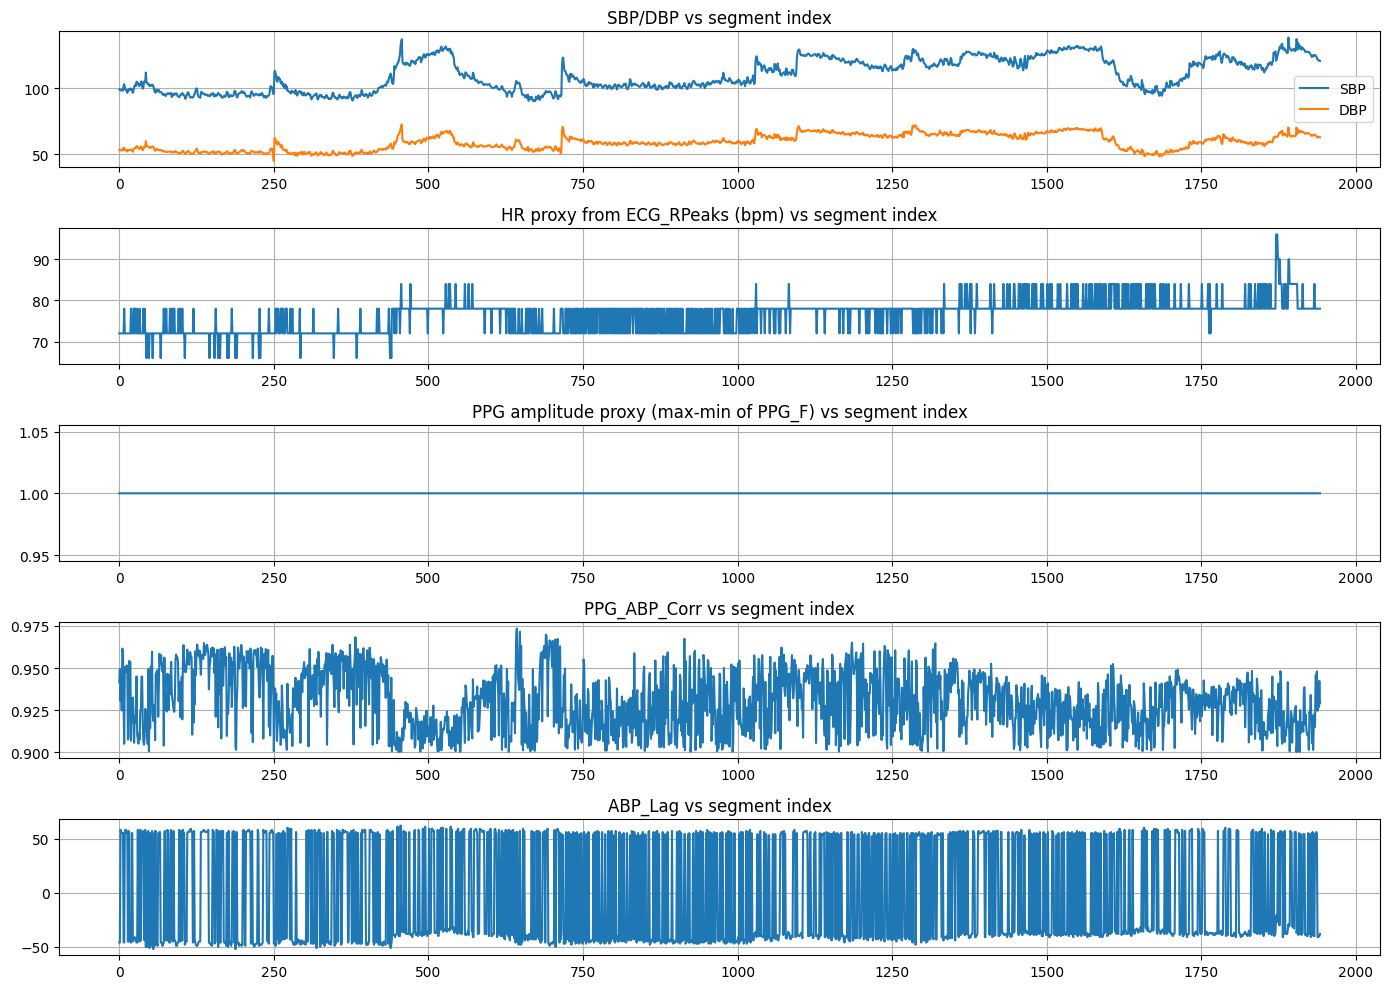

In [11]:
import h5py, numpy as np, matplotlib.pyplot as plt

MAT_FILE = "/content/drive/MyDrive/Colab Notebooks/PusleDB/p043774.mat"

def read_vec(f, ref):
    return np.array(f[ref][()]).squeeze()

def read_scalar(f, ref):
    return float(np.array(f[ref][()]).reshape(-1)[0])

with h5py.File(MAT_FILE, "r") as f:
    sw = f["Subj_Wins"]
    n = len(sw["PPG_F"][0])

    sbp = np.zeros(n, np.float32)
    dbp = np.zeros(n, np.float32)
    corr = np.zeros(n, np.float32)
    lag  = np.zeros(n, np.float32)

    # HR(ECG_RPeaks로 간단 추정): 10초 window에서 R-peak 개수로 bpm 근사
    hr = np.zeros(n, np.float32)

    # PPG amplitude proxy: (max-min) of PPG_F in each window
    ppg_amp = np.zeros(n, np.float32)

    for i in range(n):
        sbp[i] = read_scalar(f, sw["SegSBP"][0][i])
        dbp[i] = read_scalar(f, sw["SegDBP"][0][i])
        corr[i]= read_scalar(f, sw["PPG_ABP_Corr"][0][i])
        lag[i] = read_scalar(f, sw["ABP_Lag"][0][i])

        ppg = read_vec(f, sw["PPG_F"][0][i])
        ppg_amp[i] = float(ppg.max() - ppg.min())

        rpk = read_vec(f, sw["ECG_RPeaks"][0][i])
        # rpk가 비어있지 않으면 bpm ~ (#beats / 10s)*60
        hr[i] = (len(rpk) / 10.0) * 60.0 if rpk.size > 0 else np.nan

x = np.arange(n)

print("SBP mean±std:", float(sbp.mean()), float(sbp.std()))
print("DBP mean±std:", float(dbp.mean()), float(dbp.std()))
print("HR (nan 제외) mean±std:", float(np.nanmean(hr)), float(np.nanstd(hr)))

plt.figure(figsize=(14,10))

ax1 = plt.subplot(5,1,1)
ax1.plot(x, sbp, label="SBP")
ax1.plot(x, dbp, label="DBP")
ax1.set_title("SBP/DBP vs segment index")
ax1.grid(True); ax1.legend()

ax2 = plt.subplot(5,1,2, sharex=ax1)
ax2.plot(x, hr)
ax2.set_title("HR proxy from ECG_RPeaks (bpm) vs segment index")
ax2.grid(True)

ax3 = plt.subplot(5,1,3, sharex=ax1)
ax3.plot(x, ppg_amp)
ax3.set_title("PPG amplitude proxy (max-min of PPG_F) vs segment index")
ax3.grid(True)

ax4 = plt.subplot(5,1,4, sharex=ax1)
ax4.plot(x, corr)
ax4.set_title("PPG_ABP_Corr vs segment index")
ax4.grid(True)

ax5 = plt.subplot(5,1,5, sharex=ax1)
ax5.plot(x, lag)
ax5.set_title("ABP_Lag vs segment index")
ax5.grid(True)

plt.tight_layout()
plt.show()


In [12]:
# 여러 segment에서 PPG_F의 min/max가 거의 동일한지 확인
import h5py, numpy as np

MAT_FILE = "/content/drive/MyDrive/Colab Notebooks/PusleDB/p043774.mat"

def read_vec(f, ref):
    return np.array(f[ref][()]).squeeze()

mins, maxs, amps = [], [], []
with h5py.File(MAT_FILE, "r") as f:
    sw = f["Subj_Wins"]
    n = len(sw["PPG_F"][0])
    for i in range(n):
        x = read_vec(f, sw["PPG_F"][0][i])
        mins.append(x.min()); maxs.append(x.max()); amps.append(x.max()-x.min())

print("PPG_F min range:", (min(mins), max(mins)))
print("PPG_F max range:", (min(maxs), max(maxs)))
print("PPG_F amp range:", (min(amps), max(amps)))


PPG_F min range: (np.float64(0.0), np.float64(0.0))
PPG_F max range: (np.float64(0.9999999999999999), np.float64(1.0))
PPG_F amp range: (np.float64(0.9999999999999999), np.float64(1.0))
